Detected ns5_vector as [time, channels]. Keeping as-is.

Final aligned shapes:
ns5_vector: torch.Size([5851861, 32])
trainKin: torch.Size([5851861, 7])
trainNIPtime: torch.Size([5851861])
ns5_sample: torch.Size([5851861])

Good trial counts by kept gesture:
G0: 12
G1: 10
G2: 10
G3: 11
G4: 10

Excluded gesture trial counts:
G5: 10 excluded trials
G6: 10 excluded trials

Raw all_trials: 53
Removed short trials: 0
Excluded gesture trials: 20

Available trial_num values by gesture:
G0: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
G1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
G2: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
G3: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
G4: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Processing all_trials exactly once with auto-relabel/artifact masking:
  10/53
  20/53
  30/53
  40/53
  50/53
  53/53

Saved NEW labeled manual-clean-split dataset:
C:/Users/Micah/utah-neuro/MATLAB_Jupyter\Gesture_Trial_Dataset_Labeled.pt

Final fixed split:
Train: 43
Val: 5
Test: 5
All trials: 53

Val trials:
  G0 trial_

,Dataset split,All-zero trainKin rows,Non-all-zero trainKin rows,Total rows,All-zero %,Non-all-zero %
0,train,3052969,328815,3381784,90.28,9.72
1,val,370202,51414,421616,87.81,12.19
2,test,346539,49525,396064,87.50,12.50
3,all_trials,3769710,429754,4199464,89.77,10.23



Label extension summary:


,gesture,trial_num,active_length,segment_length,label_extension_added_samples,label_extension_added_ms,rest_after_original_label,rest_after_extended_label
0,0,1,29432,68760,15000,500.00,39328,24328
1,0,2,36272,85232,15000,500.00,48960,33960
2,0,3,37080,88560,15000,500.00,51480,36480
3,0,4,29700,79860,15000,500.00,50160,35160
4,0,5,27900,77012,15000,500.00,49112,34112
5,0,6,1392,1528,136,4.53,136,0
6,0,7,31980,85260,15000,500.00,53280,38280
7,0,8,29040,81060,15000,500.00,52020,37020
8,0,9,29672,79408,15000,500.00,49736,34736
9,0,10,16920,21064,4144,138.13,4144,0



Artifact / event summary:

all_trials
  trials: 53
  events: 53
  detected bursts: 48 / 53
  invalid fraction: 0.2914
  extreme spike seconds: 2.744
  bad rest seconds: 40.442

train
  trials: 43
  events: 43
  detected bursts: 38 / 43
  invalid fraction: 0.3237
  extreme spike seconds: 2.607
  bad rest seconds: 36.14

val
  trials: 5
  events: 5
  detected bursts: 5 / 5
  invalid fraction: 0.1829
  extreme spike seconds: 0.137
  bad rest seconds: 2.571

test
  trials: 5
  events: 5
  detected bursts: 5 / 5
  invalid fraction: 0.1312
  extreme spike seconds: 0.0
  bad rest seconds: 1.732

Example saved trial shapes:
ns5_vector: torch.Size([68760, 32])
trainKin_original: torch.Size([68760, 9])
trainKin_forward_extended_before_relabel: torch.Size([68760, 9])
trainKin_relabel_seed: torch.Size([68760, 9])
trainKin final auto-relabel: torch.Size([68760, 9])
valid_mask: torch.Size([68760])

Example metadata:
gesture: 0
trial_num: 1
active_length: 29432
segment length: 68760
label_extension_

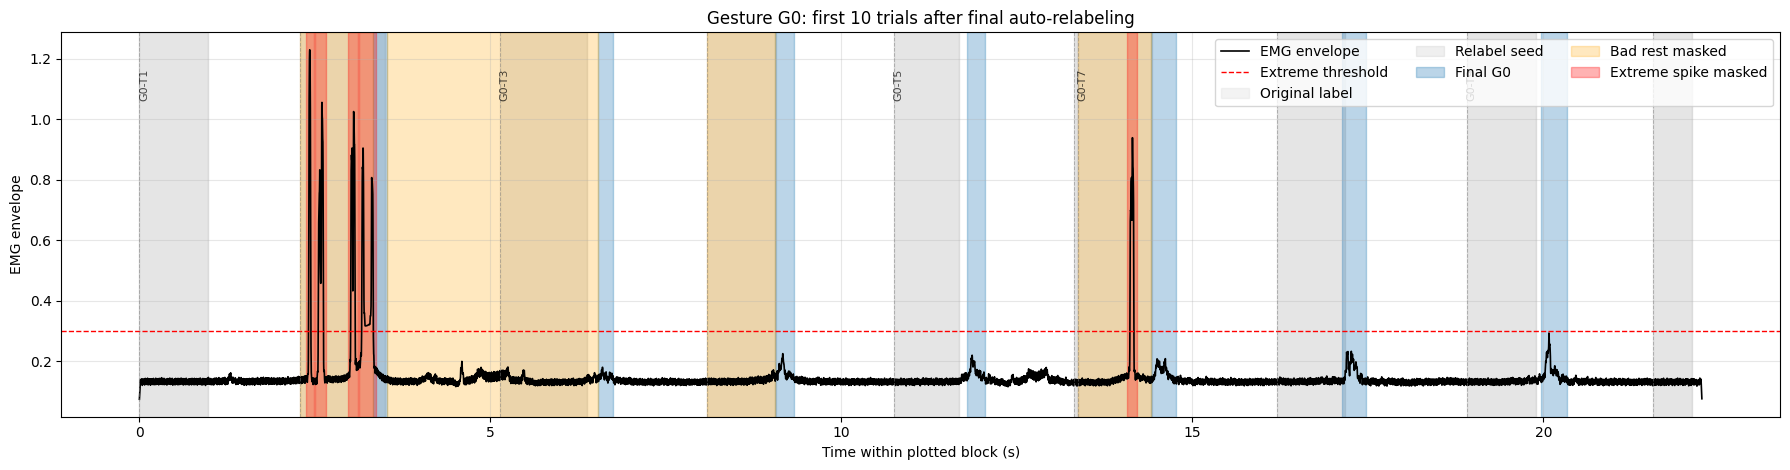

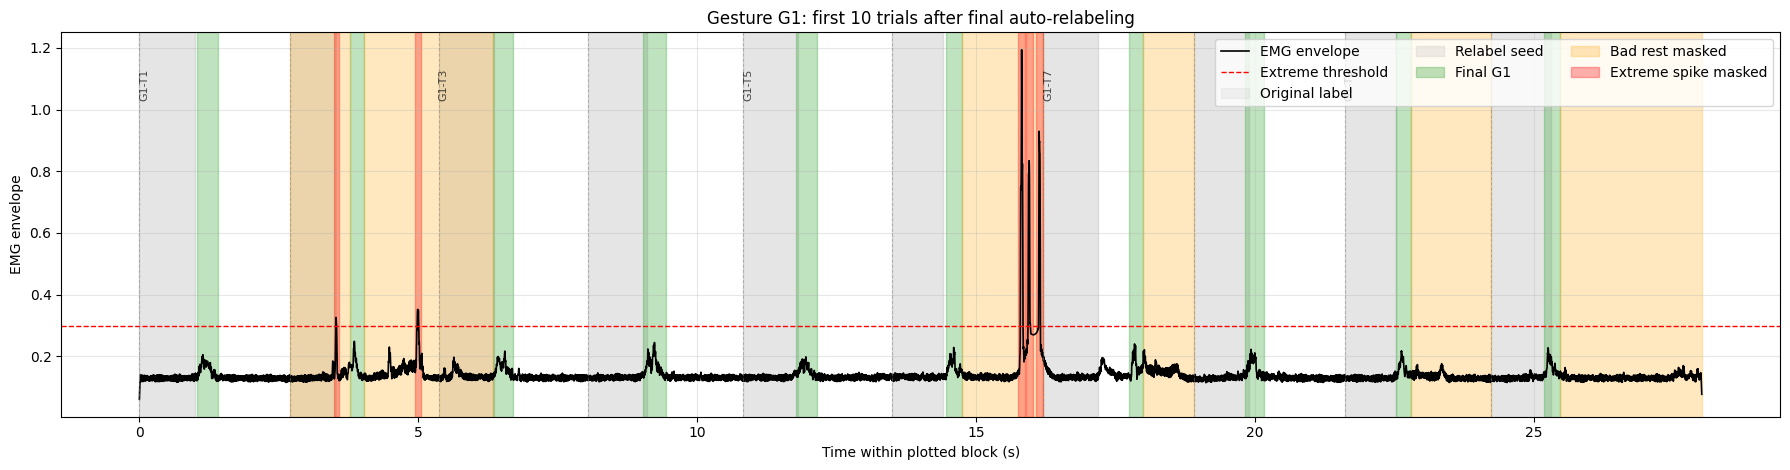

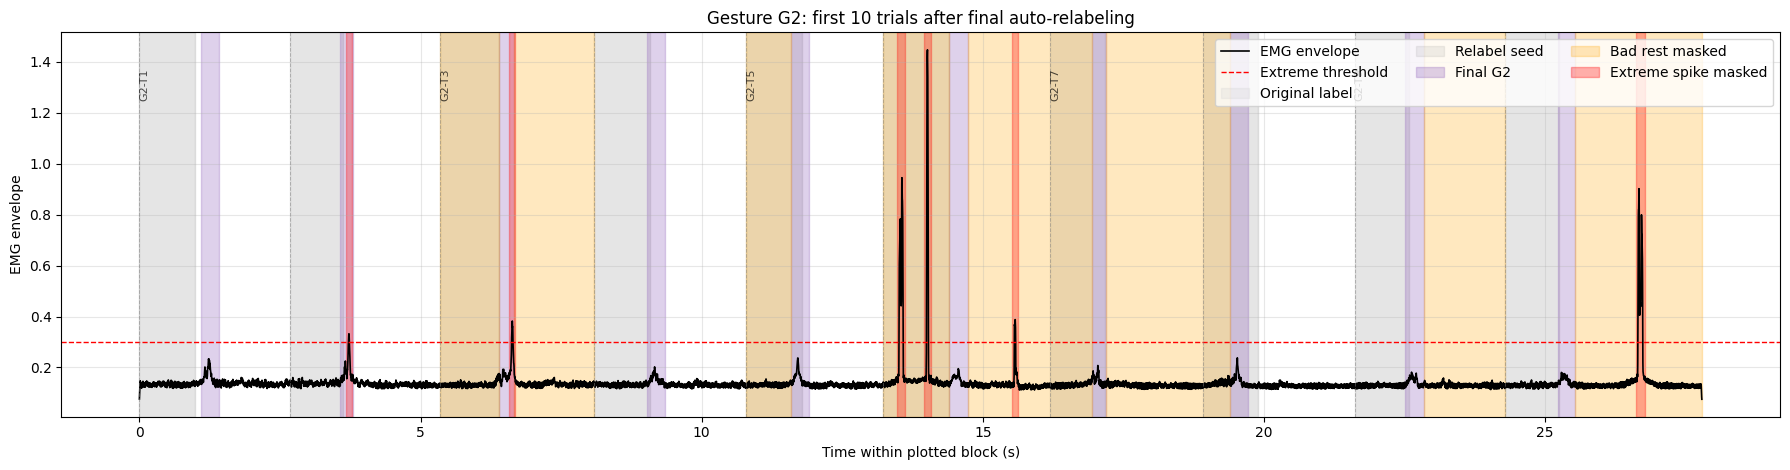

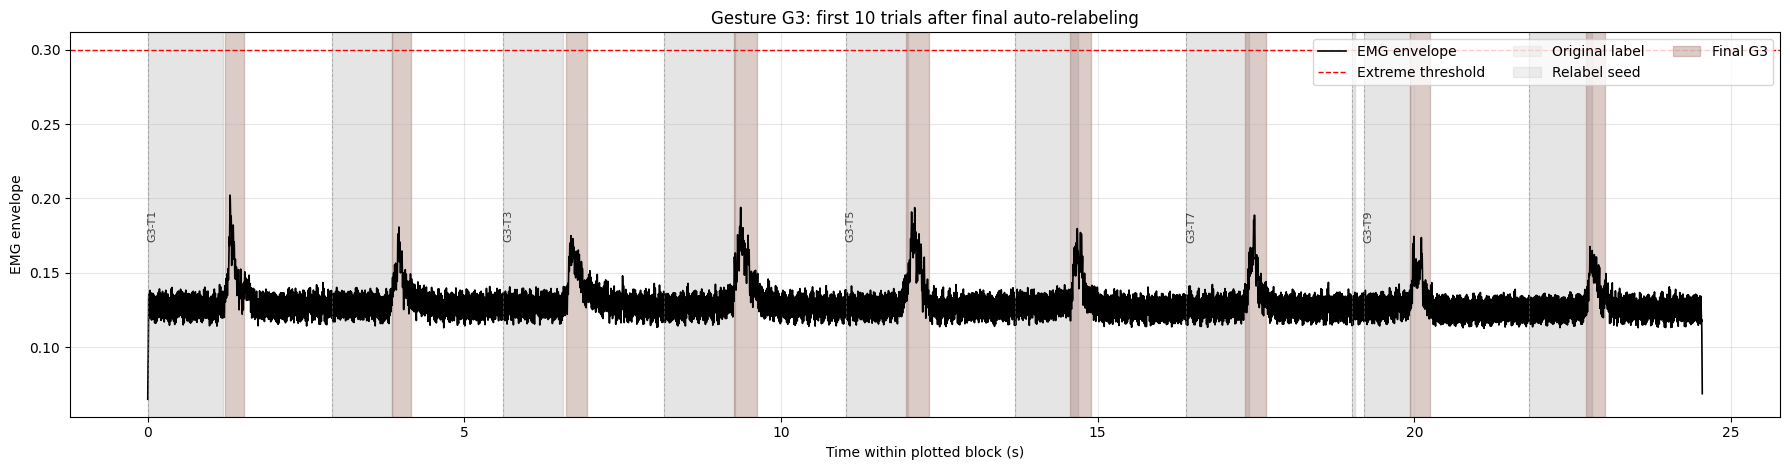

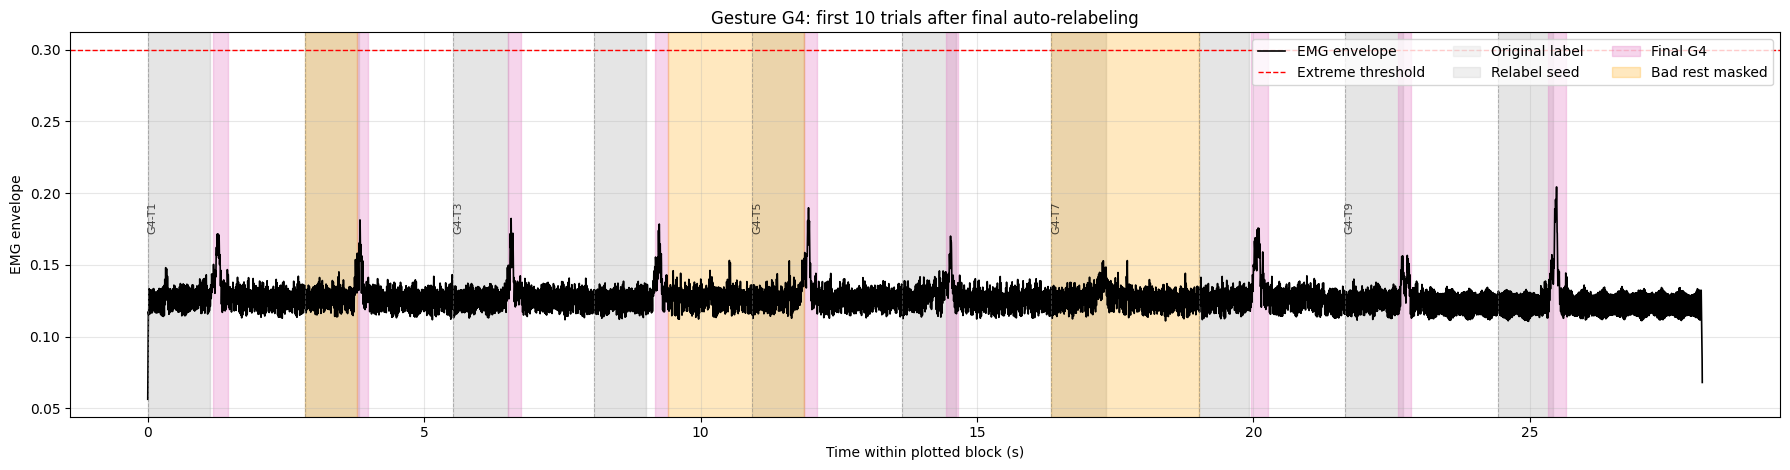


Done.
Use this file in Meta_Lockd:
C:/Users/Micah/utah-neuro/MATLAB_Jupyter\Gesture_Trial_Dataset_Labeled.pt


In [2]:
# ============================================================
# ONE-CELL LABELED DATASET PIPELINE
# Forward-extended labels + auto-relabel/artifact masking
# + fixed manual clean val/test split

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

base_dir = r"C:/Users/Micah/utah-neuro/MATLAB_Jupyter"

input_path = os.path.join(base_dir, "Aligned_Train_Data_Preprocessed.pt")

output_path = os.path.join(
    base_dir,
    "Gesture_Trial_Dataset_Labeled.pt"
)


# ------------------------------------------------------------
# Manual fixed clean val/test split
# ------------------------------------------------------------
# Edit these after inspecting trial quality.

MANUAL_VAL_TEST_TRIALS = {
    0: {"val": 7, "test": 8},
    1: {"val": 4, "test": 5},
    2: {"val": 4, "test": 5},
    3: {"val": 4, "test": 5},
    4: {"val": 4, "test": 5},
}


# ------------------------------------------------------------
# Main settings
# ------------------------------------------------------------

fs = 30000

KEPT_CLASSES = 5
label_names = ["G0", "G1", "G2", "G3", "G4"]
keep_gestures = set(MANUAL_VAL_TEST_TRIALS.keys())

# Forward extension from original prompt/active label.
LABEL_EXTEND_MS = 500
LABEL_EXTEND_SAMPLES = int(round((LABEL_EXTEND_MS / 1000) * fs))

# Minimum active block length to count as valid trial.
min_length = 20

# Which label to use as seed for auto-relabel search.
#
# False = use original prompt labels as the relabel seed.
# This matches your previous auto-relabel behavior because it preferred
# trainKin_original when available.
#
# True = use forward-extended labels as the relabel seed.
USE_EXTENDED_LABELS_AS_RELABEL_SEED = False


# ------------------------------------------------------------
# Auto-relabel / artifact masking settings
# ------------------------------------------------------------

ENVELOPE_WINDOW_MS = 25
ACTIVITY_MAD_MULT = 1.5
LOW_MAD_MULT = 0.75
MIN_BURST_MS = 12

SEARCH_BEFORE_MS = 100
SEARCH_AFTER_MS = 700

PRE_PAD_MS = 40
POST_PAD_MS = 120

EXTREME_SPIKE_ENV_THRESHOLD = 0.3
EXTREME_SPIKE_PAD_MS = 40

BAD_REST_MAD_MULT = 3.0


# ------------------------------------------------------------
# Plotting settings
# ------------------------------------------------------------

MAKE_CHECK_PLOTS = True
TRIALS_PER_BLOCK = 10
MAX_PLOT_POINTS = 10000

gesture_colors = ["tab:blue", "tab:green", "tab:purple", "tab:brown", "tab:pink"]


# ============================================================
# General helpers
# ============================================================

def to_cpu_tensor(x, dtype=None):
    if torch.is_tensor(x):
        x = x.detach().cpu()
        if dtype is not None:
            x = x.to(dtype)
        return x

    return torch.tensor(x, dtype=dtype)


def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().float().numpy()

    return np.asarray(x, dtype=np.float32)


def force_ns5_time_channels(x):
    """
    Force ns5_vector to [time, 32].
    """
    x = to_cpu_tensor(x, dtype=torch.float32)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D ns5_vector, got shape {x.shape}")

    if x.shape[0] == 32 and x.shape[1] != 32:
        print("Detected ns5_vector as [channels, time]. Transposing to [time, channels].")
        x = x.T.contiguous()

    elif x.shape[1] == 32:
        print("Detected ns5_vector as [time, channels]. Keeping as-is.")

    else:
        raise ValueError(
            f"Unexpected ns5_vector shape {x.shape}. "
            "Expected [time, 32] or [32, time]."
        )

    return x


def force_trainkin_time_features(x):
    """
    Force trainKin to [time, features].
    """
    x = to_cpu_tensor(x, dtype=torch.float32)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D trainKin, got shape {x.shape}")

    if x.shape[0] <= 20 and x.shape[1] > x.shape[0]:
        print("Detected trainKin as [features, time]. Transposing to [time, features].")
        x = x.T.contiguous()

    return x


def force_1d(x, name):
    x = to_cpu_tensor(x)

    if x.ndim > 1:
        x = x.squeeze()

    if x.ndim != 1:
        raise ValueError(f"Expected {name} to be 1D after squeeze, got shape {x.shape}")

    return x


def force_emg_tc(x):
    """
    Return EMG as [T, 32].
    """
    x = to_numpy(x)

    if x.ndim != 2:
        raise ValueError(f"Bad EMG shape: {x.shape}")

    if x.shape[0] == 32 and x.shape[1] != 32:
        x = x.T

    if x.shape[1] != 32:
        raise ValueError(f"Expected 32 channels, got {x.shape}")

    return x.astype(np.float32)


def force_kin_tk(x):
    """
    Return trainKin as [T, K].
    """
    x = to_numpy(x)

    if x.ndim != 2:
        raise ValueError(f"Bad trainKin shape: {x.shape}")

    if x.shape[0] <= 20 and x.shape[1] > x.shape[0]:
        x = x.T

    return x.astype(np.float32)


def moving_average(x, win):
    win = int(max(1, win))

    if win == 1:
        return x

    k = np.ones(win, dtype=np.float32) / win
    return np.convolve(x, k, mode="same")


def envelope(emg_tc):
    env = np.mean(np.abs(emg_tc), axis=1)
    win = int((ENVELOPE_WINDOW_MS / 1000) * fs)
    return moving_average(env, win)


def robust_med_sigma(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) == 0:
        return 0.0, 1.0

    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    sigma = 1.4826 * mad

    if sigma < 1e-8:
        sigma = float(np.std(x) + 1e-8)

    return med, sigma


def intervals(mask):
    mask = np.asarray(mask).astype(bool)

    if mask.sum() == 0:
        return []

    padded = np.pad(mask.astype(np.int32), (1, 1))
    d = np.diff(padded)

    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0]

    return list(zip(starts, ends))


def expand_mask(mask, pad):
    mask = np.asarray(mask).astype(bool)

    if mask.sum() == 0 or pad <= 0:
        return mask.copy()

    out = mask.copy()

    for s, e in intervals(mask):
        ss = max(0, s - pad)
        ee = min(len(mask), e + pad)
        out[ss:ee] = True

    return out


def remove_short_runs(mask, min_len):
    out = np.zeros_like(mask, dtype=bool)

    for s, e in intervals(mask):
        if e - s >= min_len:
            out[s:e] = True

    return out


def old_label_events(old_kin):
    events = []

    for g in range(KEPT_CLASSES):
        for s, e in intervals(old_kin[:, g] > 0.5):
            events.append((s, e, g))

    return sorted(events, key=lambda x: x[0])


def crop_tensor_like(x, T):
    if x is None:
        return None

    if torch.is_tensor(x):
        return x[:T]

    arr = np.asarray(x)
    return arr[:T]


# ============================================================
# Load aligned data and force shapes
# ============================================================

aligned = torch.load(input_path, weights_only=False)

ns5_vector = aligned["ns5_vector"]
trainKin = aligned["trainKin"]
trainNIPtime = aligned["trainNIPtime"]
ns5_sample = aligned["ns5_sample"]

ns5_vector = force_ns5_time_channels(ns5_vector)
trainKin = force_trainkin_time_features(trainKin)
trainNIPtime = force_1d(trainNIPtime, "trainNIPtime")
ns5_sample = force_1d(ns5_sample, "ns5_sample")

T = ns5_vector.shape[0]

if trainKin.shape[0] != T:
    raise ValueError(
        f"Length mismatch: ns5_vector has {T} rows, trainKin has {trainKin.shape[0]}"
    )

if trainNIPtime.shape[0] != T:
    raise ValueError(
        f"Length mismatch: ns5_vector has {T} rows, trainNIPtime has {trainNIPtime.shape[0]}"
    )

if ns5_sample.shape[0] != T:
    raise ValueError(
        f"Length mismatch: ns5_vector has {T} rows, ns5_sample has {ns5_sample.shape[0]}"
    )

print("\nFinal aligned shapes:")
print("ns5_vector:", ns5_vector.shape)
print("trainKin:", trainKin.shape)
print("trainNIPtime:", trainNIPtime.shape)
print("ns5_sample:", ns5_sample.shape)


# ============================================================
# Build original and forward-extended 9-column labels
# ============================================================

trainKin_np = trainKin.cpu().numpy()

if trainKin_np.shape[1] < 7:
    raise ValueError(f"Expected trainKin to have at least 7 columns, got shape {trainKin_np.shape}")

labels7 = trainKin_np[:, :7]

is_active = np.any(labels7 == 1, axis=1)

gesture_class = np.full(len(labels7), -1)
gesture_class[is_active] = np.argmax(labels7[is_active], axis=1)

trainKin9 = torch.zeros(
    trainKin.shape[0],
    9,
    dtype=trainKin.dtype,
)

trainKin9[:, :5] = trainKin[:, :5]

trainKin9_extended = trainKin9.clone()


# ============================================================
# Detect active gesture blocks
# ============================================================

all_active_blocks = []
raw_trials = []
removed_trials = []
excluded_gesture_trials = []

in_block = False
start = None

for i in range(len(is_active)):
    if is_active[i] and not in_block:
        start = i
        in_block = True

    if in_block and (not is_active[i] or i == len(is_active) - 1):
        end = i if not is_active[i] else i + 1

        block_gestures = gesture_class[start:end]
        block_gestures = block_gestures[block_gestures >= 0]

        if len(block_gestures) == 0:
            in_block = False
            continue

        unique_gestures = np.unique(block_gestures)

        if len(unique_gestures) > 1:
            print(
                f"WARNING: mixed gesture block from {start} to {end}: "
                f"{unique_gestures}"
            )

        gesture = int(unique_gestures[0])

        block_info = {
            "gesture": gesture,
            "active_start_idx": start,
            "active_end_idx": end,
            "active_length": end - start,
            "block_index": len(all_active_blocks),
        }

        all_active_blocks.append(block_info)

        trial_info = dict(block_info)

        if end - start < min_length:
            removed_trials.append(trial_info)

        elif gesture not in keep_gestures:
            excluded_gesture_trials.append(trial_info)

        else:
            raw_trials.append(trial_info)

        in_block = False


# ============================================================
# Add segment boundaries and forward-extend labels
# ============================================================

for trial in raw_trials:
    block_index = trial["block_index"]

    segment_start = trial["active_start_idx"]

    if block_index + 1 < len(all_active_blocks):
        next_active_start = all_active_blocks[block_index + 1]["active_start_idx"]
        segment_end = next_active_start
    else:
        next_active_start = len(trainKin9)
        segment_end = min(
            trial["active_end_idx"] + LABEL_EXTEND_SAMPLES,
            len(trainKin9),
        )

    label_extended_end = min(
        trial["active_end_idx"] + LABEL_EXTEND_SAMPLES,
        segment_end,
        next_active_start,
    )

    trial["start_idx"] = segment_start
    trial["end_idx"] = segment_end
    trial["length"] = segment_end - segment_start

    trial["label_original_start_idx"] = trial["active_start_idx"]
    trial["label_original_end_idx"] = trial["active_end_idx"]
    trial["label_extended_end_idx"] = label_extended_end

    trial["label_extend_ms"] = LABEL_EXTEND_MS
    trial["label_extend_samples"] = LABEL_EXTEND_SAMPLES
    trial["label_extension_added_samples"] = label_extended_end - trial["active_end_idx"]

    trial["rest_after_original_label_length"] = segment_end - trial["active_end_idx"]
    trial["rest_after_extended_label_length"] = segment_end - label_extended_end

    g = trial["gesture"]

    trainKin9_extended[
        trial["active_start_idx"]:label_extended_end,
        :5,
    ] = 0

    trainKin9_extended[
        trial["active_start_idx"]:label_extended_end,
        g,
    ] = 1


# ============================================================
# Assign trial numbers after removing short/excluded trials
# ============================================================

gesture_counts = {g: 0 for g in sorted(keep_gestures)}

for trial in raw_trials:
    g = trial["gesture"]
    gesture_counts[g] += 1
    trial["trial_num"] = gesture_counts[g]


# ============================================================
# Build all_trials only
# No dynamic split indices.
# No rotating val/test.
# ============================================================

dataset_raw = {
    "train": [],
    "val": [],
    "test": [],
    "all_trials": [],
    "removed_trials": removed_trials,
    "excluded_gesture_trials": excluded_gesture_trials,
    "metadata": {
        "source_file": input_path,
        "fs": fs,
        "kept_gestures": sorted(list(keep_gestures)),
        "label_extend_ms": LABEL_EXTEND_MS,
        "label_extend_samples": LABEL_EXTEND_SAMPLES,
        "num_classes": 9,
        "split_type": "not_split_yet_all_trials_only",
        "split_note": (
            "This intermediate raw dataset stores all usable kept trials in all_trials only. "
            "Manual fixed train/val/test split is applied after auto-relabeling."
        ),
        "label_note": (
            "trainKin_original is original prompt/active label. "
            "trainKin_forward_extended_before_relabel is forward-extended seed label. "
            "Final trainKin after this full cell is auto-relabeled EMG-burst label."
        ),
        "use_extended_labels_as_relabel_seed": USE_EXTENDED_LABELS_AS_RELABEL_SEED,
    },
}

for trial in raw_trials:
    s = trial["start_idx"]
    e = trial["end_idx"]
    g = trial["gesture"]
    t = trial["trial_num"]

    trial_data = {
        "gesture": g,
        "trial_num": t,

        "start_idx": s,
        "end_idx": e,
        "length": e - s,

        "active_start_idx": trial["active_start_idx"],
        "active_end_idx": trial["active_end_idx"],
        "active_length": trial["active_length"],

        "label_original_start_idx": trial["label_original_start_idx"],
        "label_original_end_idx": trial["label_original_end_idx"],
        "label_extended_end_idx": trial["label_extended_end_idx"],
        "label_extend_ms": trial["label_extend_ms"],
        "label_extend_samples": trial["label_extend_samples"],
        "label_extension_added_samples": trial["label_extension_added_samples"],

        "rest_after_original_label_length": trial["rest_after_original_label_length"],
        "rest_after_extended_label_length": trial["rest_after_extended_label_length"],

        # EMG [T, 32]
        "ns5_vector": ns5_vector[s:e],

        # Original unextended labels [T, 9]
        "trainKin_original": trainKin9[s:e],

        # Forward-extended labels before auto-relabel [T, 9]
        "trainKin_forward_extended_before_relabel": trainKin9_extended[s:e],

        # Temporary trainKin before auto-relabel.
        # This gets replaced by final auto-relabeled trainKin later.
        "trainKin": trainKin9_extended[s:e],

        "trainNIPtime": trainNIPtime[s:e],
        "ns5_sample": ns5_sample[s:e],
    }

    dataset_raw["all_trials"].append(trial_data)


print("\nGood trial counts by kept gesture:")
for g in sorted(keep_gestures):
    print(f"G{g}: {gesture_counts[g]}")

print("\nExcluded gesture trial counts:")
excluded_counts = {g: 0 for g in range(7)}

for trial in excluded_gesture_trials:
    excluded_counts[trial["gesture"]] += 1

for g in range(7):
    if excluded_counts[g] > 0:
        print(f"G{g}: {excluded_counts[g]} excluded trials")

print("\nRaw all_trials:", len(dataset_raw["all_trials"]))
print("Removed short trials:", len(dataset_raw["removed_trials"]))
print("Excluded gesture trials:", len(dataset_raw["excluded_gesture_trials"]))


# ============================================================
# Print available trials before manual split
# ============================================================

def print_available_trials(all_trials):
    grouped = defaultdict(list)

    for trial in all_trials:
        grouped[int(trial["gesture"])].append(int(trial["trial_num"]))

    print("\nAvailable trial_num values by gesture:")
    for g in sorted(grouped.keys()):
        print(f"G{g}: {sorted(grouped[g])}")


print_available_trials(dataset_raw["all_trials"])


# ============================================================
# Auto-relabel / artifact masking
# ============================================================

def detect_new_window(env_det, old_s, old_e, next_s, med, sigma):
    """
    Returns:
        new_s, new_e, detected, high_thr, low_thr

    If no EMG feature crosses ACTIVITY_MAD_MULT,
    detected=False and the old label window becomes rest.
    """

    T_env = len(env_det)

    high_thr = med + ACTIVITY_MAD_MULT * sigma
    low_thr = med + LOW_MAD_MULT * sigma

    search_before = int(SEARCH_BEFORE_MS / 1000 * fs)
    search_after = int(SEARCH_AFTER_MS / 1000 * fs)
    min_burst = int(MIN_BURST_MS / 1000 * fs)

    pre_pad = int(PRE_PAD_MS / 1000 * fs)
    post_pad = int(POST_PAD_MS / 1000 * fs)

    ss = max(0, old_s - search_before)

    if next_s is None:
        ee = min(T_env, old_e + search_after)
    else:
        ee = min(T_env, next_s, old_e + search_after)

    if ee <= ss:
        return None, None, False, high_thr, low_thr

    seg = env_det[ss:ee]

    high = remove_short_runs(seg > high_thr, min_burst)
    runs = intervals(high)

    if len(runs) == 0:
        return None, None, False, high_thr, low_thr

    best = None
    best_score = -np.inf

    for a, b in runs:
        score = float(np.sum(seg[a:b] - high_thr))

        if score > best_score:
            best_score = score
            best = (a, b)

    a, b = best

    burst_s = ss + a
    burst_e = ss + b

    while burst_s > ss and env_det[burst_s - 1] > low_thr:
        burst_s -= 1

    while burst_e < ee and env_det[burst_e] > low_thr:
        burst_e += 1

    new_s = max(0, burst_s - pre_pad)
    new_e = min(T_env, burst_e + post_pad)

    if new_e <= new_s:
        return None, None, False, high_thr, low_thr

    return new_s, new_e, True, high_thr, low_thr


def process_trial(trial):
    out = dict(trial)

    emg = force_emg_tc(trial["ns5_vector"])

    if USE_EXTENDED_LABELS_AS_RELABEL_SEED:
        if "trainKin_forward_extended_before_relabel" in trial:
            old_kin_full = force_kin_tk(trial["trainKin_forward_extended_before_relabel"])
        else:
            old_kin_full = force_kin_tk(trial["trainKin"])
    else:
        if "trainKin_original" in trial:
            old_kin_full = force_kin_tk(trial["trainKin_original"])
        else:
            old_kin_full = force_kin_tk(trial["trainKin"])

    T_trial = min(emg.shape[0], old_kin_full.shape[0])

    emg = emg[:T_trial]
    old_kin_full = old_kin_full[:T_trial]

    old_kin = old_kin_full[:, :KEPT_CLASSES]
    env = envelope(emg)

    old_active = old_kin.sum(axis=1) > 0.5
    old_rest = ~old_active

    if old_rest.sum() > int(0.1 * fs):
        med, sigma = robust_med_sigma(env[old_rest])
    else:
        med, sigma = robust_med_sigma(env)

    bad_rest_thr = med + BAD_REST_MAD_MULT * sigma

    # Extreme spike mask, including label windows.
    extreme_mask = env > EXTREME_SPIKE_ENV_THRESHOLD
    extreme_mask = expand_mask(
        extreme_mask,
        int(EXTREME_SPIKE_PAD_MS / 1000 * fs),
    )

    # Suppress extreme artifacts before detecting labels.
    env_det = env.copy()
    env_det[extreme_mask] = med

    events = old_label_events(old_kin)
    new_kin = np.zeros_like(old_kin, dtype=np.float32)
    auto_events = []

    for i, (old_s, old_e, g) in enumerate(events):
        next_s = events[i + 1][0] if i + 1 < len(events) else None

        new_s, new_e, detected, high_thr, low_thr = detect_new_window(
            env_det,
            old_s,
            old_e,
            next_s,
            med,
            sigma,
        )

        if detected:
            new_kin[new_s:new_e, g] = 1.0

        auto_events.append({
            "gesture": int(g),

            "old_start": int(old_s),
            "old_end": int(old_e),

            "new_start": int(new_s) if detected else None,
            "new_end": int(new_e) if detected else None,

            "detected": bool(detected),
            "converted_to_rest": bool(not detected),

            "activity_threshold": float(high_thr),
            "low_threshold": float(low_thr),
        })

    # Bad rest intervals after relabeling.
    new_active = new_kin.sum(axis=1) > 0.5
    new_rest = ~new_active

    bad_rest_mask = np.zeros(T_trial, dtype=bool)

    for s, e in intervals(new_rest):
        if e <= s:
            continue

        rest_seg = env[s:e]

        if np.max(rest_seg) > bad_rest_thr or np.max(rest_seg) > EXTREME_SPIKE_ENV_THRESHOLD:
            bad_rest_mask[s:e] = True

    bad_rest_mask[new_active] = False

    valid_mask = np.ones(T_trial, dtype=np.float32)
    valid_mask[bad_rest_mask] = 0.0
    valid_mask[extreme_mask] = 0.0

    # Final auto-relabeled 9-column trainKin.
    new_kin_full = np.zeros_like(old_kin_full, dtype=np.float32)
    new_kin_full[:, :KEPT_CLASSES] = new_kin

    # Save standardized/cropped arrays.
    out["ns5_vector"] = torch.tensor(emg, dtype=torch.float32)

    if "trainKin_original" in out:
        out["trainKin_original"] = torch.tensor(
            force_kin_tk(out["trainKin_original"])[:T_trial],
            dtype=torch.float32,
        )

    if "trainKin_forward_extended_before_relabel" in out:
        out["trainKin_forward_extended_before_relabel"] = torch.tensor(
            force_kin_tk(out["trainKin_forward_extended_before_relabel"])[:T_trial],
            dtype=torch.float32,
        )

    out["trainKin_relabel_seed"] = torch.tensor(old_kin_full, dtype=torch.float32)
    out["trainKin"] = torch.tensor(new_kin_full, dtype=torch.float32)

    if "trainNIPtime" in out:
        out["trainNIPtime"] = crop_tensor_like(out["trainNIPtime"], T_trial)

    if "ns5_sample" in out:
        out["ns5_sample"] = crop_tensor_like(out["ns5_sample"], T_trial)

    out["valid_mask"] = torch.tensor(valid_mask, dtype=torch.float32)

    out["bad_rest_mask"] = torch.tensor(
        bad_rest_mask.astype(np.float32),
        dtype=torch.float32,
    )

    out["extreme_spike_mask"] = torch.tensor(
        extreme_mask.astype(np.float32),
        dtype=torch.float32,
    )

    out["auto_label_events"] = auto_events

    out["auto_label_metadata"] = {
        "activity_mad_mult": ACTIVITY_MAD_MULT,
        "low_mad_mult": LOW_MAD_MULT,
        "min_burst_ms": MIN_BURST_MS,
        "search_before_ms": SEARCH_BEFORE_MS,
        "search_after_ms": SEARCH_AFTER_MS,
        "pre_pad_ms": PRE_PAD_MS,
        "post_pad_ms": POST_PAD_MS,
        "extreme_spike_env_threshold": EXTREME_SPIKE_ENV_THRESHOLD,
        "bad_rest_threshold": float(bad_rest_thr),
        "invalid_fraction": float((valid_mask == 0).mean()),
        "use_extended_labels_as_relabel_seed": bool(USE_EXTENDED_LABELS_AS_RELABEL_SEED),
    }

    return out


print("\nProcessing all_trials exactly once with auto-relabel/artifact masking:")

processed_all_trials = []

for i, trial in enumerate(dataset_raw["all_trials"]):
    processed_all_trials.append(process_trial(trial))

    if (i + 1) % 10 == 0 or (i + 1) == len(dataset_raw["all_trials"]):
        print(f"  {i + 1}/{len(dataset_raw['all_trials'])}")


# ============================================================
# Manual fixed split
# ============================================================

def build_manual_fixed_split(dataset, manual_split):
    train_trials = []
    val_trials = []
    test_trials = []

    for trial in dataset["all_trials"]:
        g = int(trial["gesture"])
        t = int(trial["trial_num"])

        if g not in manual_split:
            continue

        val_t = int(manual_split[g]["val"])
        test_t = int(manual_split[g]["test"])

        if val_t == test_t:
            raise ValueError(f"G{g}: val and test trial_num cannot be the same.")

        if t == val_t:
            val_trials.append(trial)
        elif t == test_t:
            test_trials.append(trial)
        else:
            train_trials.append(trial)

    for g in sorted(manual_split.keys()):
        val_count = sum(int(tr["gesture"]) == g for tr in val_trials)
        test_count = sum(int(tr["gesture"]) == g for tr in test_trials)
        train_count = sum(int(tr["gesture"]) == g for tr in train_trials)

        if val_count != 1:
            available = sorted([
                int(tr["trial_num"])
                for tr in dataset["all_trials"]
                if int(tr["gesture"]) == g
            ])
            raise RuntimeError(
                f"G{g}: expected 1 val trial, found {val_count}. "
                f"Available trial_num values: {available}"
            )

        if test_count != 1:
            available = sorted([
                int(tr["trial_num"])
                for tr in dataset["all_trials"]
                if int(tr["gesture"]) == g
            ])
            raise RuntimeError(
                f"G{g}: expected 1 test trial, found {test_count}. "
                f"Available trial_num values: {available}"
            )

        if train_count < 1:
            raise RuntimeError(f"G{g}: no training trials left after holdout.")

    dataset["train"] = train_trials
    dataset["val"] = val_trials
    dataset["test"] = test_trials

    if "metadata" not in dataset or not isinstance(dataset["metadata"], dict):
        dataset["metadata"] = {}

    dataset["metadata"]["split_type"] = "manual_fixed_clean_holdout"
    dataset["metadata"]["manual_val_test_trials"] = manual_split
    dataset["metadata"]["kept_gestures_for_split"] = sorted(manual_split.keys())
    dataset["metadata"]["split_note"] = (
        "Fixed blind split. Val/test trials are manually selected clean held-out trials "
        "and are never used for training. No dynamic split rotation is used."
    )

    # Explicitly remove dynamic fields if any were inherited.
    dataset.pop("dynamic_split_indices", None)
    dataset["metadata"].pop("num_rotating_splits", None)

    return dataset


# Build final dataset.
final_dataset = {
    "train": [],
    "val": [],
    "test": [],
    "all_trials": processed_all_trials,
    "removed_trials": removed_trials,
    "excluded_gesture_trials": excluded_gesture_trials,
    "metadata": dict(dataset_raw["metadata"]),
}

final_dataset["metadata"]["processing_note"] = (
    "This file was generated directly from aligned data. "
    "It includes forward-extension metadata, auto-relabeled trainKin, artifact masks, "
    "valid_mask, and a fixed manual clean val/test split."
)

final_dataset = build_manual_fixed_split(
    dataset=final_dataset,
    manual_split=MANUAL_VAL_TEST_TRIALS,
)


# ============================================================
# Summary helpers
# ============================================================

def get_trainKin_balance(trials, key="trainKin"):
    zero_rows = 0
    nonzero_rows = 0

    for trial in trials:
        y = trial[key]

        if torch.is_tensor(y):
            y_np = y.detach().cpu().numpy()
        else:
            y_np = np.asarray(y)

        row_is_zero = np.all(y_np == 0, axis=1)

        zero_rows += int(np.sum(row_is_zero))
        nonzero_rows += int(np.sum(~row_is_zero))

    total_rows = zero_rows + nonzero_rows

    if total_rows > 0:
        zero_percent = 100 * zero_rows / total_rows
        nonzero_percent = 100 * nonzero_rows / total_rows
    else:
        zero_percent = 0
        nonzero_percent = 0

    return zero_rows, nonzero_rows, total_rows, zero_percent, nonzero_percent


def summarize_masks_and_events(dataset):
    for key in ["all_trials", "train", "val", "test"]:
        total = 0
        invalid = 0
        extreme = 0
        bad_rest = 0
        detected = 0
        events = 0

        for trial in dataset[key]:
            valid = to_numpy(trial["valid_mask"])
            ext = to_numpy(trial["extreme_spike_mask"])
            bad = to_numpy(trial["bad_rest_mask"])

            total += len(valid)
            invalid += int((valid == 0).sum())
            extreme += int(ext.sum())
            bad_rest += int(bad.sum())

            for ev in trial["auto_label_events"]:
                events += 1
                detected += int(ev["detected"])

        print(f"\n{key}")
        print("  trials:", len(dataset[key]))
        print("  events:", events)
        print("  detected bursts:", detected, "/", events)
        print("  invalid fraction:", round(invalid / max(1, total), 4))
        print("  extreme spike seconds:", round(extreme / fs, 3))
        print("  bad rest seconds:", round(bad_rest / fs, 3))


# ============================================================
# Save
# ============================================================

torch.save(final_dataset, output_path)

print("\nSaved NEW labeled manual-clean-split dataset:")
print(output_path)

print("\nFinal fixed split:")
print("Train:", len(final_dataset["train"]))
print("Val:", len(final_dataset["val"]))
print("Test:", len(final_dataset["test"]))
print("All trials:", len(final_dataset["all_trials"]))

print("\nVal trials:")
for tr in final_dataset["val"]:
    print(f"  G{int(tr['gesture'])} trial_num={int(tr['trial_num'])}")

print("\nTest trials:")
for tr in final_dataset["test"]:
    print(f"  G{int(tr['gesture'])} trial_num={int(tr['trial_num'])}")


# ============================================================
# Tables / diagnostics
# ============================================================

balance_rows = []

for split_name in ["train", "val", "test", "all_trials"]:
    zero_rows, nonzero_rows, total_rows, zero_percent, nonzero_percent = get_trainKin_balance(
        final_dataset[split_name],
        key="trainKin",
    )

    balance_rows.append({
        "Dataset split": split_name,
        "All-zero trainKin rows": zero_rows,
        "Non-all-zero trainKin rows": nonzero_rows,
        "Total rows": total_rows,
        "All-zero %": round(zero_percent, 2),
        "Non-all-zero %": round(nonzero_percent, 2),
    })

balance_table = pd.DataFrame(balance_rows)

print("\nFinal auto-relabel trainKin label balance table:")
try:
    display(balance_table)
except NameError:
    print(balance_table)


extension_rows = []

for trial in raw_trials:
    extension_rows.append({
        "gesture": trial["gesture"],
        "trial_num": trial["trial_num"],
        "active_length": trial["active_length"],
        "segment_length": trial["length"],
        "label_extension_added_samples": trial["label_extension_added_samples"],
        "label_extension_added_ms": round(1000 * trial["label_extension_added_samples"] / fs, 2),
        "rest_after_original_label": trial["rest_after_original_label_length"],
        "rest_after_extended_label": trial["rest_after_extended_label_length"],
    })

extension_table = pd.DataFrame(extension_rows)

print("\nLabel extension summary:")
try:
    display(extension_table.head(30))
except NameError:
    print(extension_table.head(30))


print("\nArtifact / event summary:")
summarize_masks_and_events(final_dataset)


# ============================================================
# Shape confirmation
# ============================================================

if len(final_dataset["all_trials"]) > 0:
    example_trial = final_dataset["all_trials"][0]

    print("\nExample saved trial shapes:")
    print("ns5_vector:", example_trial["ns5_vector"].shape)
    print("trainKin_original:", example_trial["trainKin_original"].shape)
    print(
        "trainKin_forward_extended_before_relabel:",
        example_trial["trainKin_forward_extended_before_relabel"].shape,
    )
    print("trainKin_relabel_seed:", example_trial["trainKin_relabel_seed"].shape)
    print("trainKin final auto-relabel:", example_trial["trainKin"].shape)
    print("valid_mask:", example_trial["valid_mask"].shape)

    print("\nExample metadata:")
    print("gesture:", example_trial["gesture"])
    print("trial_num:", example_trial["trial_num"])
    print("active_length:", example_trial["active_length"])
    print("segment length:", example_trial["length"])
    print("label_extension_added_samples:", example_trial["label_extension_added_samples"])
    print(
        "label_extension_added_ms:",
        1000 * example_trial["label_extension_added_samples"] / fs,
    )
    print("rest_after_original_label_length:", example_trial["rest_after_original_label_length"])
    print("rest_after_extended_label_length:", example_trial["rest_after_extended_label_length"])

    example_trainKin = example_trial["trainKin"]
    print("Last 4 final trainKin columns sum:", example_trainKin[:, 5:].sum().item())


# ============================================================
# QC plots
# ============================================================

def group_trials_by_gesture(trials):
    grouped = {g: [] for g in range(KEPT_CLASSES)}

    for trial in trials:
        g = int(trial["gesture"])
        if g in grouped:
            grouped[g].append(trial)

    for g in grouped:
        grouped[g] = sorted(
            grouped[g],
            key=lambda tr: int(tr.get("trial_num", 0)),
        )

    return grouped


def plot_trials_fast(trials, title):
    if len(trials) == 0:
        return

    emgs = []
    original_labels = []
    seed_labels = []
    final_labels = []
    bads = []
    extremes = []
    bounds = []
    trial_labels = []

    cursor = 0

    for trial in trials:
        emg = force_emg_tc(trial["ns5_vector"])

        orig_kin = force_kin_tk(trial["trainKin_original"])[:, :KEPT_CLASSES]
        seed_kin = force_kin_tk(trial["trainKin_relabel_seed"])[:, :KEPT_CLASSES]
        final_kin = force_kin_tk(trial["trainKin"])[:, :KEPT_CLASSES]

        bad = to_numpy(trial["bad_rest_mask"])
        ext = to_numpy(trial["extreme_spike_mask"])

        T_plot_trial = min(
            emg.shape[0],
            orig_kin.shape[0],
            seed_kin.shape[0],
            final_kin.shape[0],
            len(bad),
            len(ext),
        )

        emgs.append(emg[:T_plot_trial])
        original_labels.append(orig_kin[:T_plot_trial])
        seed_labels.append(seed_kin[:T_plot_trial])
        final_labels.append(final_kin[:T_plot_trial])
        bads.append(bad[:T_plot_trial])
        extremes.append(ext[:T_plot_trial])

        bounds.append((cursor, cursor + T_plot_trial))
        trial_labels.append(f"G{int(trial['gesture'])}-T{int(trial['trial_num'])}")

        cursor += T_plot_trial

    emg_all = np.concatenate(emgs, axis=0)
    original_all = np.concatenate(original_labels, axis=0)
    seed_all = np.concatenate(seed_labels, axis=0)
    final_all = np.concatenate(final_labels, axis=0)
    bad_all = np.concatenate(bads, axis=0)
    ext_all = np.concatenate(extremes, axis=0)

    env = envelope(emg_all)

    T_plot = len(env)
    t = np.arange(T_plot) / fs

    step = max(1, T_plot // MAX_PLOT_POINTS)
    idx = np.arange(0, T_plot, step)

    t_plot = t[idx]
    env_plot = env[idx]

    plt.figure(figsize=(18, 4.8))

    plt.plot(
        t_plot,
        env_plot,
        color="black",
        linewidth=1.2,
        label="EMG envelope",
    )

    plt.axhline(
        EXTREME_SPIKE_ENV_THRESHOLD,
        color="red",
        linestyle="--",
        linewidth=1.0,
        label="Extreme threshold",
    )

    # Original labels: light gray
    for j, (s, e) in enumerate(intervals(original_all.sum(axis=1) > 0.5)):
        plt.axvspan(
            s / fs,
            e / fs,
            color="lightgray",
            alpha=0.25,
            label="Original label" if j == 0 else None,
        )

    # Relabel seed labels: darker gray outline-ish shading
    for j, (s, e) in enumerate(intervals(seed_all.sum(axis=1) > 0.5)):
        plt.axvspan(
            s / fs,
            e / fs,
            color="gray",
            alpha=0.12,
            label="Relabel seed" if j == 0 else None,
        )

    # Final labels: gesture colors
    for g in range(KEPT_CLASSES):
        for j, (s, e) in enumerate(intervals(final_all[:, g] > 0.5)):
            plt.axvspan(
                s / fs,
                e / fs,
                color=gesture_colors[g],
                alpha=0.30,
                label=f"Final {label_names[g]}" if j == 0 else None,
            )

    # Bad rest: orange
    for j, (s, e) in enumerate(intervals(bad_all > 0.5)):
        plt.axvspan(
            s / fs,
            e / fs,
            color="orange",
            alpha=0.25,
            label="Bad rest masked" if j == 0 else None,
        )

    # Extreme spikes: red
    for j, (s, e) in enumerate(intervals(ext_all > 0.5)):
        plt.axvspan(
            s / fs,
            e / fs,
            color="red",
            alpha=0.30,
            label="Extreme spike masked" if j == 0 else None,
        )

    y_top = max(float(np.max(env_plot)) if len(env_plot) > 0 else 1.0, 1e-6)

    for k, (s, e) in enumerate(bounds):
        plt.axvline(
            s / fs,
            color="gray",
            linestyle="--",
            linewidth=0.7,
            alpha=0.5,
        )

        if k % 2 == 0:
            plt.text(
                s / fs,
                y_top * 0.95,
                trial_labels[k],
                rotation=90,
                va="top",
                ha="left",
                fontsize=8,
                alpha=0.7,
            )

    plt.title(title)
    plt.xlabel("Time within plotted block (s)")
    plt.ylabel("EMG envelope")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right", ncol=3)
    plt.tight_layout()
    plt.show()


if MAKE_CHECK_PLOTS:
    grouped = group_trials_by_gesture(final_dataset["all_trials"])

    for g in range(KEPT_CLASSES):
        gesture_trials = grouped[g]

        if len(gesture_trials) == 0:
            continue

        block = gesture_trials[:TRIALS_PER_BLOCK]

        plot_trials_fast(
            block,
            title=f"Gesture G{g}: first {len(block)} trials after final auto-relabeling",
        )

print("\nDone.")
print("Use this file in Meta_Lockd:")
print(output_path)